In [1]:
import numpy as np 
import matplotlib.pyplot as plt 

In [3]:
from sklearn.datasets import load_digits

In [81]:
digits = load_digits()
x = digits.data 
y = digits.target

In [7]:
print(x.shape)
print(x.dtype)

(1797, 64)
float64


In [8]:
print(y.shape)
print(y.dtype)

(1797,)
int64


In [9]:
print(x[0])

[ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]


In [10]:
print(y[0])

0


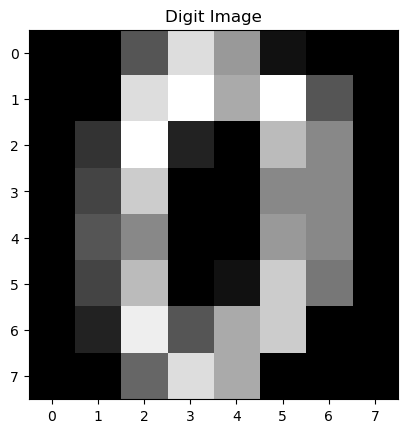

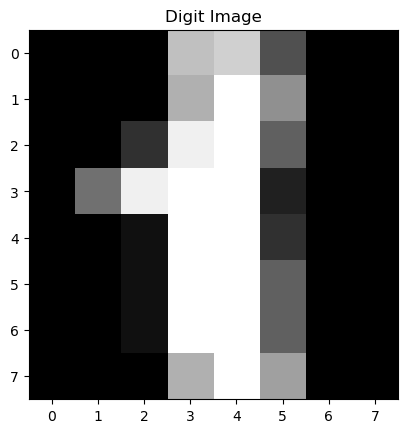

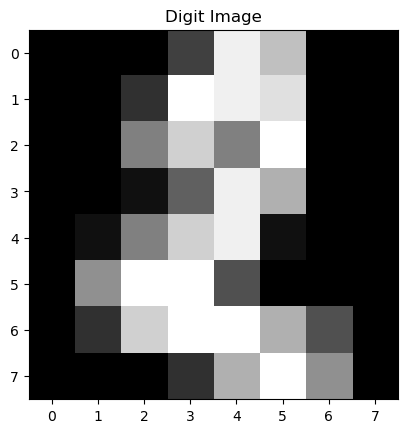

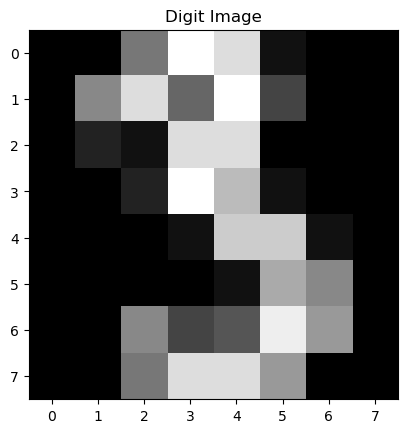

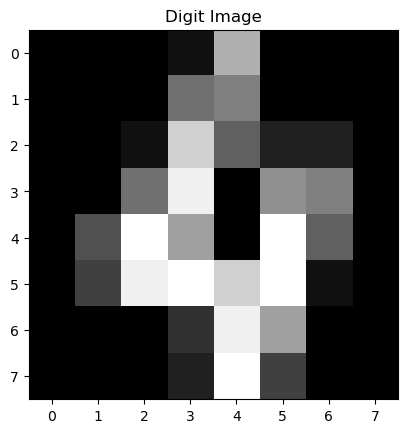

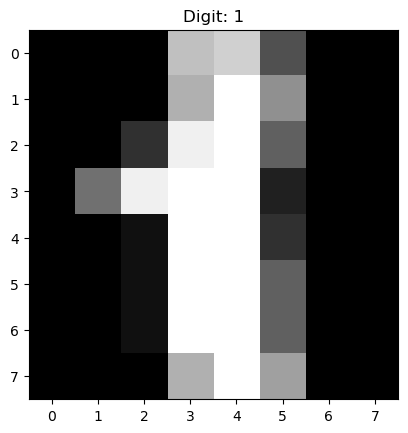

In [ ]:
for image in digits.images[:5]:
    plt.imshow(image, cmap='gray')
    plt.title('Digit Image')
    plt.show()


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [82]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)


In [83]:
train_x, test_x, train_y, test_y = train_test_split(
    x_scaled, y, test_size=0.2, random_state=42
)

In [84]:
print(train_x.shape, test_x.shape, train_y.shape, test_y.shape)

(1437, 64) (360, 64) (1437,) (360,)


In [85]:
# now we have dataset 80% in training and 20% in testing with 1437 rows in training and 360 rows in testing

def one_hot(y):
    one_hot_y= np.zeros((y.size, y.max()+1))
    one_hot_y[np.arange(y.size), y]=1
    return one_hot_y

y_one_hot = one_hot(y)
print(y_one_hot.shape)
print(y_one_hot[0])
print(y_one_hot[8])
print(y_one_hot[9])

(1797, 10)
[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


In [86]:

def initialized_parameters_deep(layer_dims):
    np.random.seed(3)
    w1 = np.random.randn(layer_dims[1], layer_dims[0]) * 0.01
    b1 = np.zeros((layer_dims[1], 1))
    w2 = np.random.randn(layer_dims[2], layer_dims[1]) * 0.01
    b2 = np.zeros((layer_dims[2], 1))

    return w1, b1, w2, b2

w1, b1, w2, b2 = initialized_parameters_deep([64, 32, 10])


In [89]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=0, keepdims=True))
    return exp_z / exp_z.sum(axis=0, keepdims=True)

def forward_propagation(X, w1, b1, w2, b2):
    z1 = np.dot(w1, X.T) + b1
    a1 = sigmoid(z1)
    z2 = np.dot(w2, a1) + b2
    a2 = softmax(z2)    
    
    return a1, a2

def compute_cost(a2, Y):
    m = Y.shape[0]
    log_probs = -np.log(a2.T[range(m), Y])
    cost = np.sum(log_probs) / m
    return cost



In [90]:
A1 , A2 = forward_propagation(train_x, w1, b1, w2, b2)
cost = compute_cost(A2, train_y)
print("Cost after forward propagation:", cost)

Cost after forward propagation: 2.3030028987647575


In [91]:
def back_propagation(X,Y,A1, A2, w2):
    m = X.shape[0]
    one_hot_Y = one_hot(Y)

    dz2 = A2 - one_hot_Y.T
    dw2 = (1/m) * np.dot(dz2, A1.T)
    db2 = (1/m) * np.sum(dz2, axis=1, keepdims=True)
    

    da1 = np.dot(w2.T, dz2)
    dz1 = da1 * A1 * (1 - A1)
    dw1 = (1/m) * np.dot(dz1, X)
    db1 = (1/m) * np.sum(dz1, axis=1, keepdims=True)    
    return dw1, db1, dw2, db2


In [92]:
dW1, db1, dW2, db2 = back_propagation(train_x, train_y, A1, A2, w2)

print("dW1 shape:", dW1.shape) # Should be (10, 64)
print("db1 shape:", db1.shape) # Should be (10, 1)
print("dW2 shape:", dW2.shape) # Should be (10, 10)
print("db2 shape:", db2.shape) # Should be (10, 1)

dW1 shape: (32, 64)
db1 shape: (32, 1)
dW2 shape: (10, 32)
db2 shape: (10, 1)


In [93]:

def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, learning_rate):
    W1 = W1 - learning_rate * dW1
    b1 = b1 - learning_rate * db1
    W2 = W2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2
    
    return W1, b1, W2, b2


In [130]:
def gradient_descent(x , y , learning_rate, iterations):
    accuracy_list = []
    iterations_list = []
    costs = []
    w1, b1, w2, b2 = initialized_parameters_deep([64, 32, 10])
    for i in range(iterations):
        A1 ,A2 = forward_propagation(x, w1, b1, w2, b2)
        cost = compute_cost(A2, y)
        dW1, db1, dW2, db2 = back_propagation(x, y, A1, A2, w2)
        w1, b1, w2, b2 = update_params(w1, b1, w2, b2, dW1, db1, dW2, db2, learning_rate)
        if i % 100 == 0:
            _, test_A2 = forward_propagation(x, w1, b1, w2, b2)
            test_prediction = np.argmax(test_A2, axis=0)
            accuracy = np.mean(test_prediction == y) * 100
            print(f"Iteration {i}, Cost: {cost}, Test Accuracy: {accuracy}%")
            costs.append(cost)
            iterations_list.append(i)
            accuracy_list.append(accuracy)
    plt.plot(iterations_list, costs)
    plt.xlabel('Iterations')
    plt.ylabel('Cost')
    plt.title('Cost vs Iterations')
    plt.show()

    plt.plot(iterations_list, accuracy_list)
    plt.xlabel('Iterations')
    plt.ylabel('Accuracy')
    plt.title('Accuracy vs Iterations')
    plt.show()
    return w1,b1,w2,b2


Iteration 0, Cost: 2.3030028987647575, Test Accuracy: 9.394572025052192%
Iteration 100, Cost: 2.2785732844585067, Test Accuracy: 17.18858733472512%
Iteration 200, Cost: 1.9874251316354383, Test Accuracy: 63.32637439109256%
Iteration 300, Cost: 1.3711551687798278, Test Accuracy: 74.80862908837857%
Iteration 400, Cost: 0.9407132521169025, Test Accuracy: 82.95059151009046%
Iteration 500, Cost: 0.6891782836614874, Test Accuracy: 87.54349338900487%
Iteration 600, Cost: 0.5313074943785091, Test Accuracy: 90.46624913013221%
Iteration 700, Cost: 0.42213890831915074, Test Accuracy: 93.1106471816284%
Iteration 800, Cost: 0.34405647614574847, Test Accuracy: 94.1544885177453%
Iteration 900, Cost: 0.2879265348196659, Test Accuracy: 94.91997216423104%
Iteration 1000, Cost: 0.2469644277045004, Test Accuracy: 95.82463465553236%
Iteration 1100, Cost: 0.21625870750690881, Test Accuracy: 96.4509394572025%
Iteration 1200, Cost: 0.19255051044754226, Test Accuracy: 97.00765483646487%
Iteration 1300, Cost: 0

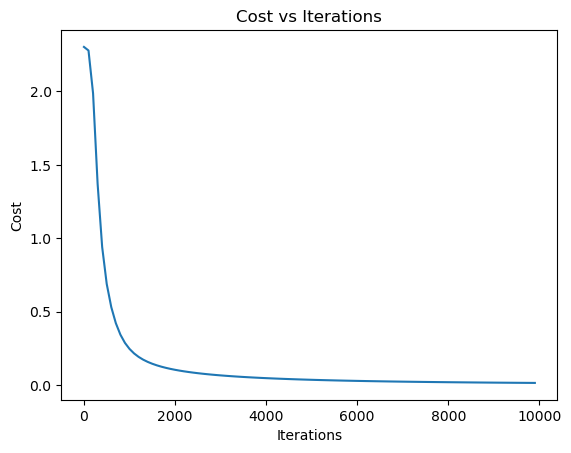

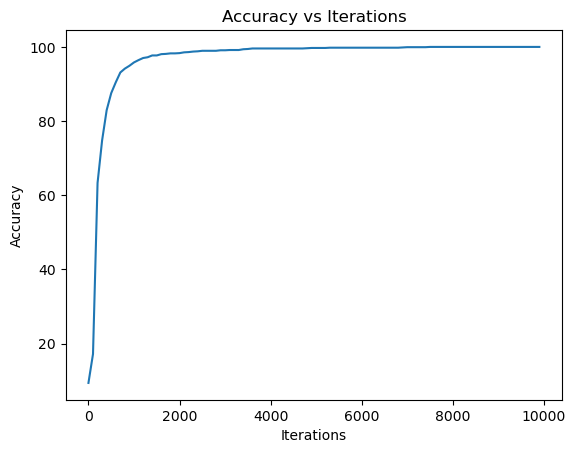

In [131]:
w1,b1,w2,b2 = gradient_descent(train_x, train_y, learning_rate=0.1, iterations=10000)

In [134]:
#perfect weights and biases

print("Trained weights and biases:")
print("w1:", w1)    
print("b1:", b1)
print("w2:", w2 )
print("b2:", b2)

Trained weights and biases:
w1: [[ 0.01788628 -0.39242687 -0.20972536 ...  0.17901403 -0.11313939
   0.02926265]
 [-0.00674728  0.07352797  0.19718409 ...  0.55652648  0.13411855
   0.02755789]
 [-0.00648411  0.17448644  0.06762967 ... -0.27417097 -0.34330553
  -0.36207969]
 ...
 [ 0.01671648  0.09942798 -0.68693323 ... -0.00769971  0.18214385
   0.09399726]
 [-0.01825644  0.18022165  0.30730108 ... -0.30318044 -0.34458386
   0.19188635]
 [ 0.01059517 -0.01330929  0.10852785 ... -0.50728145 -0.20199392
  -0.35407113]]
b1: [[-0.04166873]
 [ 0.25713653]
 [ 0.18381817]
 [ 0.00351087]
 [-0.09507475]
 [-0.25447426]
 [-0.02151255]
 [-0.05558319]
 [-0.33145862]
 [-0.06892102]
 [-0.15423004]
 [-0.14344836]
 [-0.07918786]
 [ 0.7424989 ]
 [-0.15892117]
 [-0.34699657]
 [ 0.28116089]
 [ 0.40751023]
 [ 0.09629874]
 [-0.39926339]
 [ 0.15337037]
 [ 0.23176714]
 [ 0.18861992]
 [ 0.18648996]
 [ 0.21746883]
 [ 0.30397886]
 [ 0.07361457]
 [ 0.02766733]
 [ 0.06446514]
 [-0.05061045]
 [-0.14209693]
 [ 0.09